Hybrid Method 2 (cosine only) — NDCG & Recall in one figure

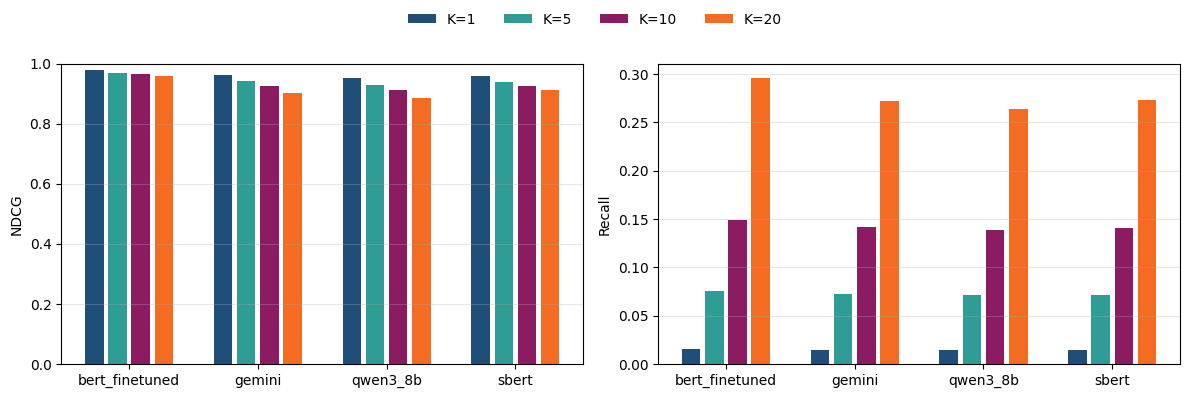

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# فایل نتایج
XLSX = "hybrid_weighted_rrf_summary.xlsx"
SHEET = "Summary"

K_LIST = [1, 5, 10, 20]

# خواندن داده
df = pd.read_excel(XLSX, sheet_name=SHEET, engine="openpyxl")

# فقط cosine
df = df[df["metric"].astype(str).str.lower() == "cosine"].copy()
df["K"] = df["K"].astype(int)
df = df[df["K"].isin(K_LIST)]

# pivot tables
pivot_ndcg = df.pivot_table(
    index="embedding",
    columns="K",
    values="ndcg@K",
    aggfunc="mean"
).sort_index()

pivot_recall = df.pivot_table(
    index="embedding",
    columns="K",
    values="recall@K",
    aggfunc="mean"
).sort_index()

embeddings = pivot_ndcg.index.tolist()
x = np.arange(len(embeddings))
bar_w = 0.18

colors = ["#1f4e79", "#2f9c95", "#8b1c62", "#f36c21"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---------- NDCG ----------
ax = axes[0]
for j, K in enumerate(K_LIST):
    ax.bar(
        x + (j - (len(K_LIST) - 1) / 2) * bar_w,
        pivot_ndcg[K].values,
        # width=bar_w,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )

# ax.set_title("Hybrid Weighted RRF — NDCG@K (cosine)")
ax.set_ylabel("NDCG")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

# ---------- Recall ----------
ax = axes[1]
for j, K in enumerate(K_LIST):
    ax.bar(
        x + (j - (len(K_LIST) - 1) / 2) * bar_w,
        pivot_recall[K].values,
        # width=bar_w,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )

# ax.set_title("Hybrid Weighted RRF — Recall@K (cosine)")
ax.set_ylabel("Recall")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")
ax.grid(axis="y", alpha=0.3)

# legend 
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [ ]:
FIG_NAME = "Hybrid2_Weighted_RRF_Search_NDGC_Accuracy_cosine.png"

fig.savefig(
    FIG_NAME,
    dpi=600,              
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME)

✅ Figure saved as: Hybrid2_Weighted_RRF_Search_NDGC_Accuracy_cosine.png


Extract the Final Precision and MRR Table for the Paper

In [ ]:
import pandas as pd

df = pd.read_excel("hybrid_weighted_rrf_summary.xlsx", sheet_name="Summary")

#  cosine
df = df[df["metric"].str.lower()=="cosine"]

# Precision table
prec = df.pivot_table(
    index="embedding",
    columns="K",
    values="precision@K",
    aggfunc="mean"
)

# MRR
mrr = df.groupby("embedding")["mrr@K"].mean()

table = prec.copy()
table["MRR"] = mrr

print(table.round(4))

K                    1       5      10      20     MRR
embedding                                             
bert_finetuned  0.9776  0.9673  0.9607  0.9546  0.9794
gemini          0.9630  0.9363  0.9159  0.8872  0.9667
qwen3_8b        0.9514  0.9223  0.8998  0.8670  0.9556
sbert           0.9600  0.9315  0.9178  0.9010  0.9645


latex

In [6]:
print(table.round(4).to_latex())

\begin{tabular}{lrrrrr}
\toprule
K & 1 & 5 & 10 & 20 & MRR \\
embedding &  &  &  &  &  \\
\midrule
bert_finetuned & 0.977600 & 0.967300 & 0.960700 & 0.954600 & 0.979400 \\
gemini & 0.963000 & 0.936300 & 0.915900 & 0.887200 & 0.966700 \\
qwen3_8b & 0.951400 & 0.922300 & 0.899800 & 0.867000 & 0.955600 \\
sbert & 0.960000 & 0.931500 & 0.917800 & 0.901000 & 0.964500 \\
\bottomrule
\end{tabular}

